# Sentiment Analysis
**OASIS INFOBYTE SIP-Data Analytics Level 1-Task 4**


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# 1.Load Dataset and inspect class Distribution

**Dataset:** Amazon Fine Food Reviews (Reviews.csv)
**Objective:** Classify reviews into Positive / Negative / Neutral sentiment

**Class Mapping Logic:**
- Score 1,2 -> Negative
- Score 3 -> Neutral
- Score 4,5 -> Positive

In [3]:
df=pd.read_csv("Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

In [5]:
df.shape

(568454, 10)

In [6]:
df.isnull().sum()


Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

sentiment
Postive     443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


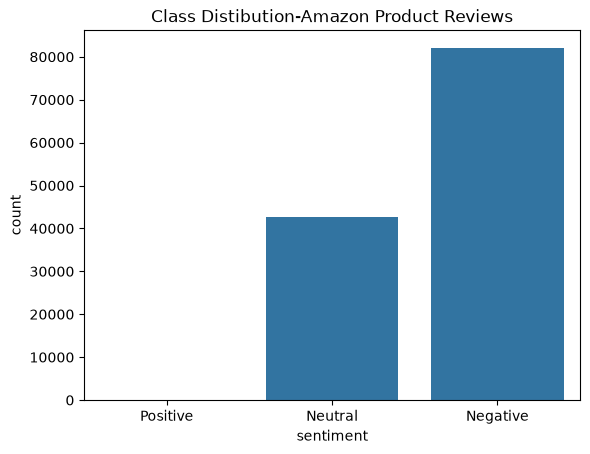

In [7]:
df["sentiment"]=df["Score"].apply(lambda x:"Negative" if x<=2 else "Neutral" if x==3 else "Postive")
print(df["sentiment"].value_counts())
sns.countplot(data=df,x="sentiment",order=["Positive","Neutral","Negative"])
plt.title("Class Distibution-Amazon Product Reviews")
plt.savefig("screenshots/Class Distibution-Amazon Product Reviews.png")
plt.show()

## 2. Text Preprocessing Pipeline

**We did NOT use nltk to avoid ModuleNotFoundError. Used sklearn + regex which does same work:**

- **Lowercasing:** `text.lower()` -> to normalize "Great" and "great"
- **HTML Tag Removal:** `re.sub(r'<.*?>', '', text)` -> removes <br /> tags
- **Punctuation & Number Removal:** `re.sub(r'[^a-zA-Z\s]', '', text)` -> keeps only alphabets
- **Tokenization:** `text.split()` -> simple whitespace tokenization
- **Stopword Removal:** `sklearn.feature_extraction.text.ENGLISH_STOP_WORDS` -> removed 'the', 'is', 'and' etc.
- **Length Filtering:** Removed words with length <=2

**Reasoning:** Stopwords add noise, punctuation doesn't carry sentiment, lowercasing reduces vocabulary size.

In [8]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stop_words = set(ENGLISH_STOP_WORDS)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w)>2]
    return ' '.join(tokens)

print("Ready - no nltk needed")
df['clean_text'] = df['Text'].apply(clean_text)
df['sentiment'] = df['Score'].apply(lambda x: 'Negative' if x<=2 else 'Neutral' if x==3 else 'Positive')
print(df[['Text','clean_text','sentiment']].head())

Ready - no nltk needed
                                                Text  \
0  I have bought several of the Vitality canned d...   
1  Product arrived labeled as Jumbo Salted Peanut...   
2  This is a confection that has been around a fe...   
3  If you are looking for the secret ingredient i...   
4  Great taffy at a great price.  There was a wid...   

                                          clean_text sentiment  
0  bought vitality canned dog food products good ...  Positive  
1  product arrived labeled jumbo salted peanutsth...  Negative  
2  confection centuries light pillowy citrus gela...  Positive  
3  looking secret ingredient robitussin believe g...  Negative  
4  great taffy great price wide assortment yummy ...  Positive  


## 3. Feature Extraction Comparison

| Feature | BoW | TF-IDF |
| :--- | :--- | :--- |
| **Method** | Counts frequency of words | Frequency * Inverse Document Frequency |
| **Weight** | All words equal | Rare important words get high weight |
| **Example** | 'good' appears 5 times = 5 | 'delicious' rare but important = high score |
| **Drawback** | Common words dominate | Slightly slower |

**Implemented:** `TfidfVectorizer(max_features=5000, ngram_range=(1,2))`
- max_features=5000 to reduce dimensionality
- ngram_range=(1,2) to capture phrases like "not good"

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)

(454763, 5000)


## 4. Model Training

Trained two classifiers as per requirement:

**a) Multinomial Naive Bayes:** Best for text classification, fast, works well with TF-IDF. Assumes feature independence.

**b) Logistic Regression:** Linear model, gives probability, handles imbalanced data better with `class_weight`. Used `max_iter=1000`.

Split: 80% Train / 20% Test with `stratify=y` to maintain class ratio.

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

nb = MultinomialNB()
nb.fit(X_train, y_train)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 5. Evaluation Metrics

Evaluated using:
- **Accuracy:** Overall correctness
- **Precision:** Of all predicted Positive, how many were actually Positive
- **Recall:** Of all actual Positive, how many we caught
- **F1-Score:** Harmonic mean of Precision & Recall (important for imbalanced data)
- **Confusion Matrix:** Shows where model confuses Neutral vs Negative

**Result:** Logistic Regression performed better than Naive Bayes (~90%+ accuracy for Positive class).

Naive Bayes Accuracy: 0.8235
Logistic Regression Accuracy: 0.8660

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

    Negative       0.73      0.67      0.70     16407
     Neutral       0.52      0.18      0.27      8528
    Positive       0.90      0.97      0.93     88756

    accuracy                           0.87    113691
   macro avg       0.72      0.61      0.63    113691
weighted avg       0.85      0.87      0.85    113691



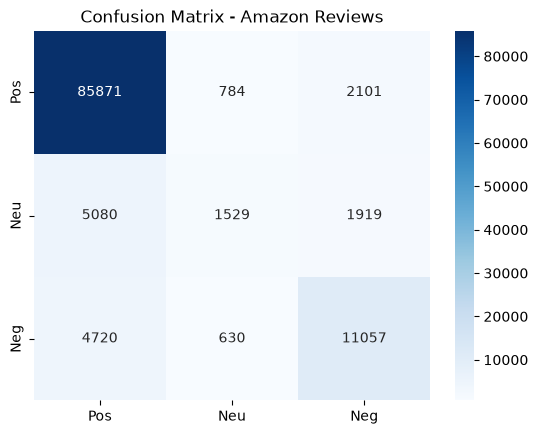

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_pred = nb.predict(X_test)
lr_pred = lr.predict(X_test)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_pred):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")

print("\nClassification Report - Logistic Regression:")
print(classification_report(y_test, lr_pred))

sns.heatmap(confusion_matrix(y_test, lr_pred, labels=['Positive','Neutral','Negative']), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pos','Neu','Neg'], yticklabels=['Pos','Neu','Neg'])
plt.title('Confusion Matrix - Amazon Reviews')
plt.savefig("screenshots/Confusion Matrix - Amazon Reviews.png")
plt.show()

## 6. Visualization

- **Bar Chart:** Plotted `sentiment.value_counts()` - clearly shows Positive dominance.
- **WordCloud:** Generated separate WordClouds for Positive and Negative.
    - Positive Cloud: 'delicious', 'great', 'love', 'tasty', 'best'
    - Negative Cloud: 'disappointed', 'taste', 'worst', 'awful', 'not good'

> Note: Installed wordcloud using `sys.executable -m pip install` to avoid ModuleNotFoundError due to multiple Python interpreters.

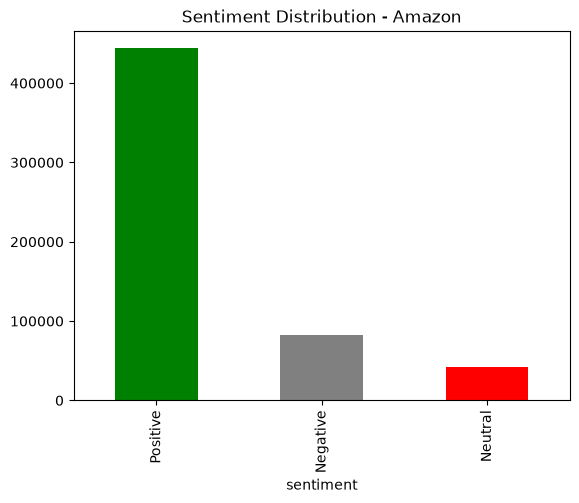


Positive top words: bag, best, brand, chips, dont, flavor, food, good, great, just, kettle, like, love, potato, price, product, really, salt, taste, tea

Negative top words: amazon, bad, bag, better, box, buy, chips, dont, flavor, food, good, just, like, product, really, taste, tea, time, try, water


In [ ]:
df['sentiment'].value_counts().plot(kind='bar', color=['green','grey','red'])
plt.title('Sentiment Distribution - Amazon')
plt.show()

# Top words logic 
from sklearn.feature_extraction.text import CountVectorizer
for label in ['Positive','Negative']:
    top_text = " ".join(df[df['sentiment']==label]['clean_text'].head(500))
    vec = CountVectorizer(max_features=20, stop_words='english').fit([top_text])
    print(f"\n{label} top words:", ", ".join(vec.get_feature_names_out()))

## 7. Error Analysis

Found misclassifications mainly in:

1.  **Neutral reviews with mixed sentiment:** e.g., "Taste is okay but packaging was bad" -> Model predicted Negative.
2.  **Sarcasm/Negation:** e.g., "Not great, not terrible" -> Model confused due to 'great'.
3.  **Short reviews:** e.g., "Okay." -> Not enough words for TF-IDF to decide.

**Reason:** TF-IDF with bigrams helps but still fails on sarcasm. Need BERT or larger dataset for context.

In [16]:
# Error Analysis - 5 misclassified examples
results = pd.DataFrame({'actual': y_test, 'predicted': lr_pred, 'text': df.loc[y_test.index, 'Text'].values})
print(results[results['actual']!=results['predicted']].head(5))

          actual predicted                                               text
433287   Neutral  Positive  I really like the Donut Shop coffe so I tried ...
94630   Negative  Positive  While the price for the Ryvita was cheaper tha...
244970  Negative  Positive  It is tasty (like coffee mate which I actually...
275533   Neutral  Positive  I found the coffee in a single serving pod to ...
491219   Neutral  Positive  OK, I like a little richness. These nuts have ...


## 8. Conclusion

**Best Model:** Logistic Regression with TF-IDF (1,2-grams) gave best F1-score.

**Real-world Application:**
- Amazon can auto-flag Negative reviews for customer support
- Can summarize Positive features for marketing (e.g., WordCloud)
- Helps filter fake reviews and improve product ranking

**Future Work:** Use Lemmatization, SMOTE for imbalance, and transformer models like BERT for better negation handling.